# Maxent playground

Forecast something *by hand*: write down variables and the beliefs you can
actually state (marginals, conditionals, correlations), and let the flow
maxent solver assemble them into a joint distribution.

**How to use:** edit the two blocks in the SETUP cell, then Run All.

Statement grammar (one string each):

```
P(x = True) = 0.3                 # binary marginal
P(x > 5.0) = 0.2                  # continuous threshold
E[x] = 4.1                        # expectation
P(y = True | x > 5.0) = 0.8       # conditional (any propositions)
E[y | x = True] = 2.0             # conditional expectation
Corr(x, y) = -0.3                 # NOT binary-binary (use a conditional)
```

Solver options worth knowing (FIT cell): `prob_penalty="logit"` treats
probability slack multiplicatively (tail-safe; elicited certainties are
softened to 0.99), `robust=True` adds per-statement credence gates that can
switch off a statement the rest of the joint contradicts, `value_rel_sd` /
`prob_logit_sd` control how hard statements pull. Statements are *soft*:
check the constraint report to see where the fit actually landed.


In [ ]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")   # remove on a GPU runtime
import numpy as np
import matplotlib.pyplot as plt
from calibrated_response.models.variable import BinaryVariable, ContinuousVariable
from calibrated_response.models.natural_response import parse_natural_syntax
from calibrated_response.maxent_sampler import DistributionBuilder

# ---- A) EDIT: variables ---------------------------------------------------
variables = [
    BinaryVariable(name="rate_cut_by_sept",
                   description="Fed cuts rates by September 2026"),
    ContinuousVariable(name="cpi_yoy_june",
                       description="US CPI YoY inflation, June 2026",
                       lower_bound=0.0, upper_bound=8.0, unit="%"),
    ContinuousVariable(name="unemployment_june",
                       description="U-3 unemployment rate, June 2026",
                       lower_bound=3.0, upper_bound=7.0, unit="%"),
]

# ---- A) EDIT: what you believe --------------------------------------------
statements = [
    "P(rate_cut_by_sept = True) = 0.55",
    "E[cpi_yoy_june] = 2.8",
    "P(cpi_yoy_june > 3.5) = 0.2",
    "P(rate_cut_by_sept = True | cpi_yoy_june > 3.5) = 0.15",
    "E[unemployment_june] = 4.3",
    "P(rate_cut_by_sept = True | unemployment_june > 4.8) = 0.85",
    "Corr(cpi_yoy_june, unemployment_june) = -0.2",
    "P(cpi_yoy_june > 4.5 | unemployment_june > 4.8) = 0.3",

]

estimates = [parse_natural_syntax(s) for s in statements]
print(f"{len(variables)} variables, {len(estimates)} statements parsed")


3 variables, 7 statements parsed


In [2]:
# ---- B) FIT ----------------------------------------------------------------
builder = DistributionBuilder(
    variables, estimates,
    prob_penalty="logit",     # or "abs"
    robust=False,             # True: per-statement credence gates
)
builder.fit(steps=1500, n_samples=2048, entropy_reg=1.0, seed=0)

for w in builder.skipped + builder.warnings:
    print("!", w)

print(f"{'statement':<52} {'target':>8} {'fitted':>8} {'p_cond':>7}  cred")
for r in builder.constraint_report(n_samples=50_000):
    flag = " <-- check" if abs(r["error_rel"]) > 0.05 else ""
    pc = f"{r['p_cond']:.3f}" if r["p_cond"] is not None else "     -"
    cred = f"{r['credence']:.2f}" if r.get("credence") is not None else "   -"
    print(f"{r['estimate'][:52]:<52} {r['target']:>8.3f} {r['fitted']:>8.3f} "
          f"{pc:>7}  {cred}{flag}")


statement                                              target   fitted  p_cond  cred
P(rate_cut_by_sept = True) = 0.55                       0.550    0.553       -     -
E[cpi_yoy_june] = 2.8                                   2.800    2.726       -     -
P(cpi_yoy_june > 3.5) = 0.2                             0.200    0.216       -     -
P(rate_cut_by_sept = True | cpi_yoy_june > 3.5) = 0.    0.150    0.178   0.216     -
E[unemployment_june] = 4.3                              4.300    4.367       -     -
P(rate_cut_by_sept = True | unemployment_june > 4.8)    0.850    0.827   0.321     -
Corr(cpi_yoy_june, unemployment_june) = -0.2           -0.200   -0.191       -     -


rate_cut_by_sept             P(True) = 0.553
cpi_yoy_june                 E =   2.718 ± 1.570   P10/50/90 = 1.09 / 2.38 / 5.00
unemployment_june            E =   4.365 ± 1.064   P10/50/90 = 3.19 / 4.08 / 6.03


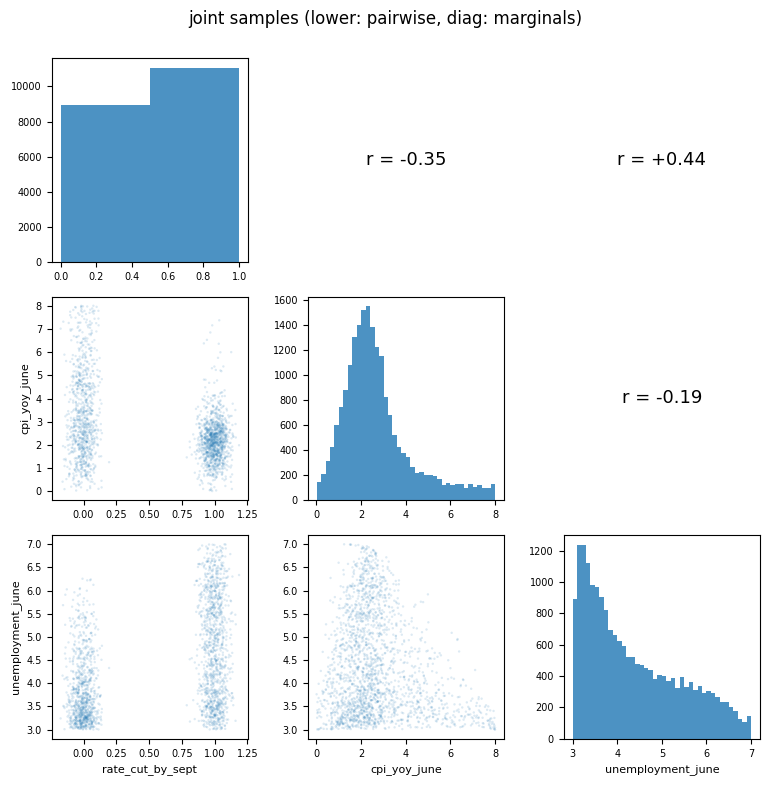

In [3]:
# ---- C) READOUT: moments + pairwise plot -----------------------------------
S = builder.sample_dict(n_samples=20_000)
names = list(S)
is_bin = {n: builder.is_binary[builder.var_name_to_idx[n]] for n in names}

for n in names:
    col = S[n]
    if is_bin[n]:
        print(f"{n:<28} P(True) = {col.mean():.3f}")
    else:
        q = np.percentile(col, [10, 50, 90])
        print(f"{n:<28} E = {col.mean():7.3f} ± {col.std():.3f}   "
              f"P10/50/90 = {q[0]:.2f} / {q[1]:.2f} / {q[2]:.2f}")

k = len(names)
sub = np.random.default_rng(0).choice(len(S[names[0]]), 2_000, replace=False)
fig, axes = plt.subplots(k, k, figsize=(2.6 * k, 2.6 * k))
axes = np.atleast_2d(axes)
jit = {n: (S[n] + np.random.default_rng(1).normal(0, 0.06, len(S[n]))
           if is_bin[n] else S[n]) for n in names}
for i, ni in enumerate(names):
    for j, nj in enumerate(names):
        ax = axes[i, j]
        if i == j:
            ax.hist(S[ni], bins=(2 if is_bin[ni] else 40),
                    color="tab:blue", alpha=0.8)
        elif i > j:
            ax.scatter(jit[nj][sub], jit[ni][sub], s=3, alpha=0.15,
                       color="tab:blue", edgecolors="none")
        else:
            r = np.corrcoef(S[nj], S[ni])[0, 1]
            ax.text(0.5, 0.5, f"r = {r:+.2f}", ha="center", va="center",
                    fontsize=13)
            ax.set_axis_off()
        if i == k - 1 and j <= i:
            ax.set_xlabel(nj, fontsize=8)
        if j == 0 and i > 0:
            ax.set_ylabel(ni, fontsize=8)
        ax.tick_params(labelsize=7)
fig.suptitle("joint samples (lower: pairwise, diag: marginals)", y=1.0)
fig.tight_layout()
plt.show()


In [ ]:
# ---- D) OPTIONAL: interrogate the joint ------------------------------------
# any conditional readout on the samples, e.g.:
mask = S["cpi_yoy_june"] > 3.5
print(f"P(rate_cut | cpi > 3.5)   = {S['rate_cut_by_sept'][mask].mean():.3f}  "
      f"(on {mask.sum()} samples)")
mask = S["rate_cut_by_sept"] > 0.5
print(f"E[unemployment | rate_cut] = {S['unemployment_june'][mask].mean():.3f}")
